In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy import stats as scipystats

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 800)
pd.set_option('display.precision', 3)
pd.set_option('display.expand_frame_repr', False)

# ***import dataprep files from both reps and concatenate*** 

In [2]:
rep1 = pd.read_csv(r"Y:\test_dfs_for_final_code\rep1_postAnalysis.csv")
rep2 = pd.read_csv(r"Y:\test_dfs_for_final_code\rep2_postAnalysis.csv")
granddata = pd.concat([rep1, rep2])
granddata = granddata.reset_index(drop = True)

# ***Fig_S1: plotting mean WHI5 mRNA count per cell for all cell cycle stages*** 

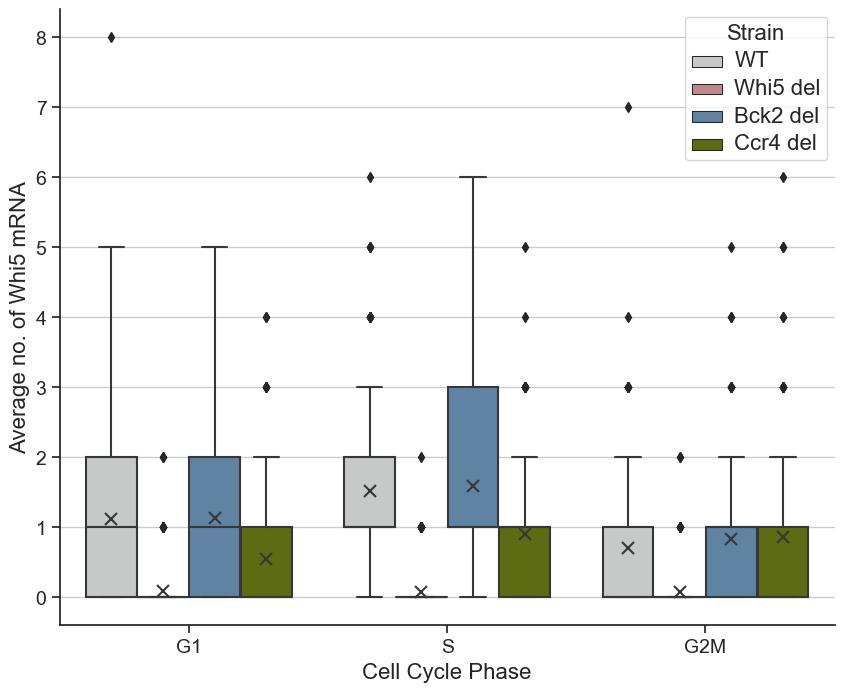

In [3]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks",{'axes.grid' : True})

PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
palette ={"WT":"#c5c9c7" , "Whi5 del": "#c87f89", "Bck2 del": "#5684ae", "Ccr4 del":"#677a04"}
p,(ax17) = plt.subplots(nrows = 1, ncols = 1, figsize = (10,8))

p = sns.boxplot(x="phase_yc", y="num_spots", order = ["G1","S", "G2M"],
            hue="Strain", data=granddata, ax=ax17, palette = palette, showmeans = True,
            hue_order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
            meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"8",
                      "markeredgewidth": 1.5},
                **PROPS)
#ax17.set_ylim(0, 8)
p.set_xlabel("Cell Cycle Phase", fontsize=16)
p.set_ylabel("Average no. of Whi5 mRNA", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.setp(p.get_legend().get_texts(), fontsize='16')
plt.setp(p.get_legend().get_title(), fontsize='16')

ax17.spines['right'].set_visible(False)
ax17.spines['top'].set_visible(False)

#save figure
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\supplement\Fig2\smFISH_Whi5_allCCstages.svg", dpi =150)
plt.show()

# ***Fig_S1: printing cell numbers in each category and statistics (independent two-tailed t-test unequal variances)*** 

In [4]:
print("spots stats S phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "S") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "S")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "S") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "S") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))


print("WT VS BCK2",scipystats.ttest_ind((WT_df["num_spots"]), (bck2del_df["num_spots"]), equal_var = False))
print("WT VS CCR4",scipystats.ttest_ind((WT_df["num_spots"]), (ccr4del_df["num_spots"]), equal_var = False))
print("WT VS WHI5",scipystats.ttest_ind((WT_df["num_spots"]), (whi5del_df["num_spots"]), equal_var = False))

print("spots stats G1 phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "G1") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "G1")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "G1") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "G1") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))

print("spots stats G2M phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "G2M") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "G2M")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "G2M") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "G2M") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))

spots stats S phase:
WT n 172
Bck2del n 211
whi5del n 182
ccr4del n 83
WT VS BCK2 TtestResult(statistic=-0.5337608651738209, pvalue=0.593822090663231, df=376.35778367063983)
WT VS CCR4 TtestResult(statistic=4.056251280434269, pvalue=7.503748860097395e-05, df=174.73369905253796)
WT VS WHI5 TtestResult(statistic=15.317522984378229, pvalue=5.617367963143639e-35, df=189.2847754886712)
spots stats G1 phase:
WT n 98
Bck2del n 196
whi5del n 121
ccr4del n 127
spots stats G2M phase:
WT n 125
Bck2del n 178
whi5del n 143
ccr4del n 130


# ***Fig_1C: plotting mean WHI5 mRNA count per cell for S-phase cells only*** 

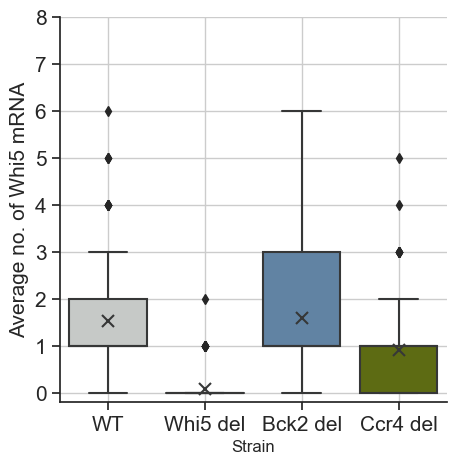

In [10]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks")

PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

p,(ax17) = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5))
palette ={"WT":"#c5c9c7" , "Whi5 del": "#c87f89", "Bck2 del": "#5684ae", "Ccr4 del":"#677a04"}
p = sns.boxplot(x="Strain", 
                y="num_spots",
                order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
                # hue_order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"], 
                # #width = 0.5,
                # hue="Strain",
                showmeans = True,
                data=granddata[granddata['phase_yc'] == "S"], 
                ax=ax17, 
                palette = palette, 
                
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"8",
                      "markeredgewidth": 1.5},
                **PROPS
                #edgecolor = "#363737", 
                #errorbar=('ci', 68)
               )


ax17.set_ylim(-0.2, 8)
ax17.spines['right'].set_visible(False)
ax17.spines['top'].set_visible(False)
#p.set_xlabel("", fontsize=15)
p.set_ylabel("Average no. of Whi5 mRNA", fontsize=15)
#plt.xticks([],fontsize=14)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#ax17.legend(bbox_to_anchor=(1.3, 1.05))
ax17.grid()





#save figure
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig1\panel3.svg", dpi =150)
plt.show()